In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
np.set_printoptions(precision=3, suppress=True)
%matplotlib widget

In [2]:
datadir = "data/magacc_pitch/readings_32"
sectorpaths = sorted(Path(datadir).glob("*"))


In [3]:
sectorpath = sectorpaths[2]
data = np.loadtxt(sectorpath, delimiter=",")
mag = data[:, 0:3] / 100.0
acc = data[:, 3:6]
gyr = data[:, 6:9]
dts = data[:, 9]


In [4]:
def affine_transform(W, m):
    y = W[:, :3] @ m.T + W[:, 3:4]
    return y.T




In [5]:
def norm_residual(y):
    r = np.linalg.norm(y, axis=1) - 1.0
    obj = np.mean(np.abs(r)**2)
    return obj

def constant_dot_product_residual(y, a):
    z = np.sum(y * a, axis=1) / (np.linalg.norm(y, axis=1) * np.linalg.norm(a, axis=1))
    r = z - np.mean(z)
    obj = np.mean(np.abs(r)**2)
    return obj



In [6]:
def sector_rotation_residual(y, acc):
    """Objective for finishSector's inverse-rotation scatter objective."""

    # Normalize accelerometer samples and estimate the great-circle normal.
    acc_unit = acc / np.linalg.norm(acc, axis=1, keepdims=True)
    scatter = acc_unit.T @ acc_unit
    eigenvalues, eigenvectors = np.linalg.eigh(scatter)
    axis = eigenvectors[:, 0]

    # Match finishSector's deterministic axis sign convention.
    axis_index = np.argmax(np.abs(axis))
    if axis[axis_index] < 0:
        axis = -axis

    # Choose a phase reference from the first projected accelerometer sample.
    e1 = acc_unit[0] - axis * np.dot(axis, acc_unit[0])
    if np.linalg.norm(e1) < 1e-6:
        e1 = eigenvectors[:, 2]
        e1 = e1 - axis * np.dot(axis, e1)
    e1 = e1 / np.linalg.norm(e1)
    e2 = np.cross(axis, e1)

    theta = np.arctan2(acc_unit @ e2, acc_unit @ e1)
    theta = np.unwrap(theta)

    # Rodrigues rotation matrices R(axis, -theta), one for each sample.
    K = np.array([
        [0.0, -axis[2], axis[1]],
        [axis[2], 0.0, -axis[0]],
        [-axis[1], axis[0], 0.0],
    ])
    I = np.eye(3)
    R = (
        np.cos(theta)[:, None, None] * I
        - np.sin(theta)[:, None, None] * K
        + (1.0 - np.cos(theta))[:, None, None] * np.outer(axis, axis)
    )

    aligned = np.einsum("nij,nj->ni", R, y)
    residuals = aligned - np.mean(aligned, axis=0, keepdims=True)
    residuals = 0.5 * np.sum(np.abs(residuals)**2, axis=1)
    objective = np.mean(residuals)
    return objective


In [7]:
def perpendicular_mag_sector_objective(y, acc):
    """Mean squared scatter of inverse-rotated mag components perpendicular to acc."""
    acc_unit = acc / np.linalg.norm(acc, axis=1, keepdims=True)

    # Estimate the sector rotation axis from the accelerometer great circle.
    scatter = acc_unit.T @ acc_unit
    _, eigenvectors = np.linalg.eigh(scatter)
    axis = eigenvectors[:, 0]
    axis_index = np.argmax(np.abs(axis))
    if axis[axis_index] < 0:
        axis = -axis

    # Use the first projected accelerometer sample as the phase reference.
    e1 = acc_unit[0] - axis * np.dot(axis, acc_unit[0])
    if np.linalg.norm(e1) < 1e-6:
        e1 = eigenvectors[:, 2] - axis * np.dot(axis, eigenvectors[:, 2])
    e1 /= np.linalg.norm(e1)
    e2 = np.cross(axis, e1)

    theta = np.unwrap(np.arctan2(acc_unit @ e2, acc_unit @ e1))

    K = np.array([
        [0.0, -axis[2], axis[1]],
        [axis[2], 0.0, -axis[0]],
        [-axis[1], axis[0], 0.0],
    ])
    I = np.eye(3)
    R = (
        np.cos(theta)[:, None, None] * I
        - np.sin(theta)[:, None, None] * K
        + (1.0 - np.cos(theta))[:, None, None] * np.outer(axis, axis)
    )

    # Remove the component parallel to gravity, then express it in one frame.
    perpendicular = y - np.sum(y * acc_unit, axis=1, keepdims=True) * acc_unit
    aligned = np.einsum("nij,nj->ni", R, perpendicular)
    centered = aligned - np.mean(aligned, axis=0, keepdims=True)
    return np.mean(np.sum(centered**2, axis=1))


In [8]:
from scipy.optimize import minimize


def load_sectors(paths):
    sectors = []
    for path in paths:
        data = np.loadtxt(path, delimiter=",")
        sectors.append((data[:, 0:3] / 30.0, data[:, 3:6]))
    return sectors


def joint_objective(W, sectors, weights=(1.0, 1.0, 1.0, 1.0), return_terms=False):
    """Weighted objective for one W evaluated jointly over every sector.

    weights = (norm, dot, rotation, perpendicular)
    """
    W = np.asarray(W).reshape(3, 4)
    terms = np.zeros(4)

    for mag_sector, acc_sector in sectors:
        y_sector = affine_transform(W, mag_sector)
        terms += np.array([
            norm_residual(y_sector),
            constant_dot_product_residual(y_sector, acc_sector),
            sector_rotation_residual(y_sector, acc_sector),
            perpendicular_mag_sector_objective(y_sector, acc_sector),
        ])

    terms /= len(sectors)
    value = np.dot(np.asarray(weights, dtype=float), terms)
    return (value, terms) if return_terms else value


def optimize_joint_calibration(sectors, W0=None, weights=(1.0, 1.0, 1.0, 1.0),
                               maxiter=10):
    """Optimize one affine calibration W against all sectors simultaneously."""
    if not sectors:
        raise ValueError("sectors must contain at least one sector")

    if W0 is None:
        W0 = np.hstack([np.eye(3), np.zeros((3, 1))])
    W0 = np.asarray(W0, dtype=float).reshape(3, 4)

    result = minimize(
        lambda parameters: joint_objective(parameters, sectors, weights),
        W0.ravel(),
        method="Powell",
        options={"maxiter": maxiter, "disp": True},
    )
    result.W = result.x.reshape(3, 4)
    result.objective, result.terms = joint_objective(
        result.W, sectors, weights, return_terms=True
    )
    return result



In [9]:
W0 = np.hstack([np.eye(3), np.zeros((3, 1))])
# Example:
sectors = load_sectors(sectorpaths)
result = optimize_joint_calibration(
    sectors,
    W0=W0,
    weights=(0.1, 1.0, 1.0, 0.1),
)
W_optimized = result.W
result.objective, result.terms


         Current function value: 0.000655
         Iterations: 10
         Function evaluations: 1238


c:\Users\vivia\miniconda3\Lib\site-packages\scipy\optimize\_minimize.py:729: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(fun, x0, args, callback, bounds, **options)


(np.float64(0.0006548311826040303), array([0.001, 0.   , 0.   , 0.001]))

In [10]:
objective_array = np.array([
    [
        norm_residual(affine_transform(W_optimized, mag_sector)),
        constant_dot_product_residual(
            affine_transform(W_optimized, mag_sector), acc_sector
        ),
        sector_rotation_residual(
            affine_transform(W_optimized, mag_sector), acc_sector
        ),
        perpendicular_mag_sector_objective(
            affine_transform(W_optimized, mag_sector), acc_sector
        ),
    ]
    for mag_sector, acc_sector in sectors
]).T

objective_array.T


array([[0.   , 0.   , 0.   , 0.   ],
       [0.001, 0.   , 0.001, 0.001],
       [0.   , 0.   , 0.   , 0.   ],
       [0.001, 0.   , 0.   , 0.001],
       [0.001, 0.   , 0.   , 0.001],
       [0.001, 0.   , 0.   , 0.001],
       [0.003, 0.   , 0.   , 0.001],
       [0.003, 0.   , 0.   , 0.001],
       [0.003, 0.   , 0.   , 0.   ],
       [0.003, 0.   , 0.   , 0.   ],
       [0.001, 0.   , 0.   , 0.001],
       [0.   , 0.   , 0.   , 0.   ],
       [0.001, 0.   , 0.   , 0.   ],
       [0.001, 0.   , 0.   , 0.001]])

In [11]:
mag, acc = sectors[3]
y = affine_transform(W_optimized, mag)
y

array([[ 0.734, -0.647,  0.059],
       [ 0.734, -0.647,  0.059],
       [ 0.734, -0.633,  0.069],
       ...,
       [ 0.736, -0.544,  0.376],
       [ 0.736, -0.544,  0.376],
       [ 0.736, -0.544,  0.376]], shape=(500, 3))

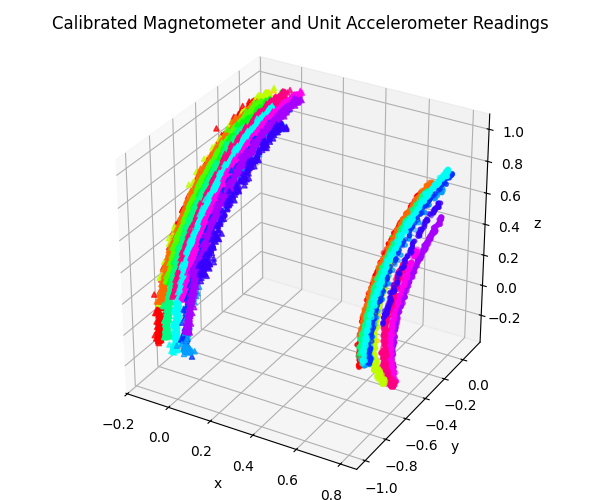

In [12]:
mag = np.vstack([s[0] for s in sectors])
acc = np.vstack([s[1] for s in sectors])

# 3D scatter plot of calibrated magnetometer readings and unit accelerometer readings.
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
colors = plt.cm.hsv(np.linspace(0.0, 1.0, len(sectors), endpoint=False))

for sector_index, (mag_sector, acc_sector) in enumerate(sectors):
    y_sector = affine_transform(W_optimized, mag_sector)
    acc_unit_sector = acc_sector / np.linalg.norm(
        acc_sector, axis=1, keepdims=True
    )
    color = colors[sector_index]

    ax.scatter(
        y_sector[:, 0], y_sector[:, 1], y_sector[:, 2],
        color=color, s=8, alpha=0.45, marker="o",
        label=f"sector {sector_index} mag",
    )
    ax.scatter(
        acc_unit_sector[:, 0], acc_unit_sector[:, 1], acc_unit_sector[:, 2],
        color=color, s=14, alpha=0.75, marker="^",
        label=f"sector {sector_index} acc",
    )

ax.set_title("Calibrated Magnetometer and Unit Accelerometer Readings")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1, 1, 1))
# ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize="small")
plt.tight_layout()
plt.show()


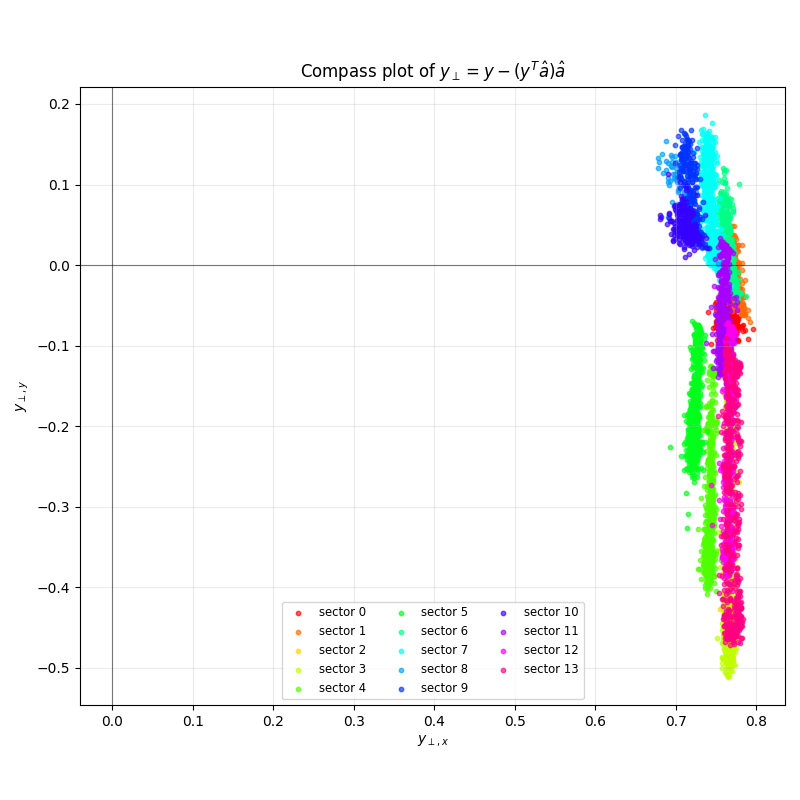

In [13]:
# Compass-style plot of the x/y components of y perpendicular to acceleration.
fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.hsv(np.linspace(0.0, 1.0, len(sectors), endpoint=False))

for sector_index, (mag_sector, acc_sector) in enumerate(sectors):
    y_sector = affine_transform(W_optimized, mag_sector)
    acc_unit_sector = acc_sector / np.linalg.norm(
        acc_sector, axis=1, keepdims=True
    )
    y_perpendicular = y_sector - np.sum(
        y_sector * acc_unit_sector, axis=1, keepdims=True
    ) * acc_unit_sector

    ax.scatter(
        y_perpendicular[:, 0],
        y_perpendicular[:, 1],
        color=colors[sector_index],
        s=10,
        alpha=0.65,
        label=f"sector {sector_index}",
    )

ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.axvline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$y_{\perp,x}$")
ax.set_ylabel(r"$y_{\perp,y}$")
ax.set_title(r"Compass plot of $y_\perp = y - (y^T\hat{a})\hat{a}$")
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize="small")
plt.tight_layout()
plt.show()


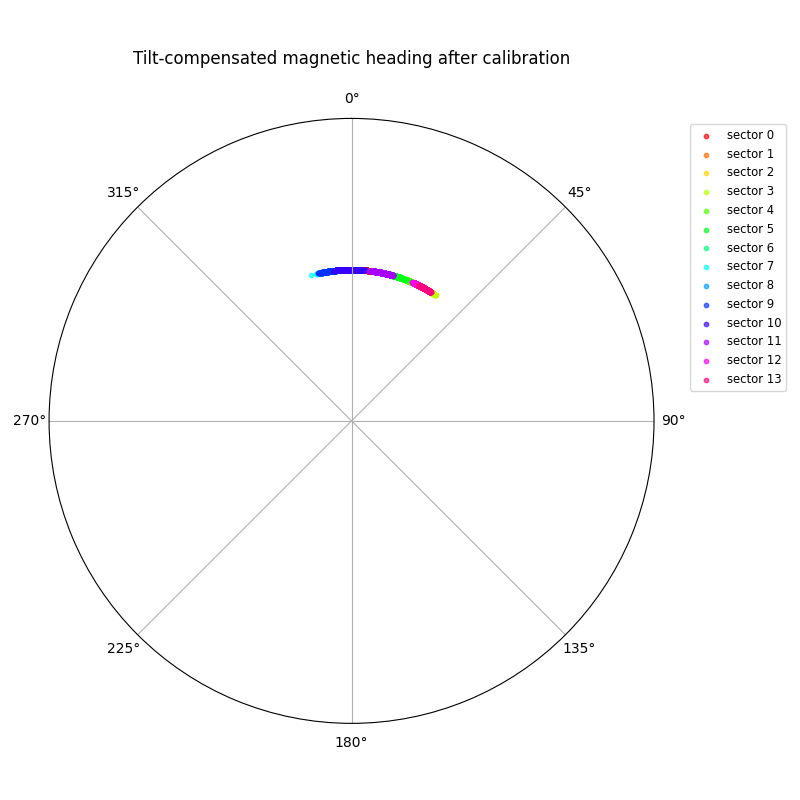

In [14]:
def tilt_compensated_heading(y, acc, declination=0.0):
    """Return magnetic heading of the sensor forward axis in radians.

    Assumes sensor x is forward and sensor y is right. The sign of the
    heading can be flipped if the accelerometer or sensor-axis convention differs.
    """
    acc_unit = acc / np.linalg.norm(acc, axis=1, keepdims=True)

    # Horizontal magnetic field: remove the gravity-parallel component.
    magnetic_horizontal = y - np.sum(y * acc_unit, axis=1, keepdims=True) * acc_unit

    forward = np.array([1.0, 0.0, 0.0])
    forward_horizontal = forward - np.sum(
        acc_unit * forward, axis=1, keepdims=True
    ) * acc_unit
    forward_horizontal /= np.linalg.norm(
        forward_horizontal, axis=1, keepdims=True
    )

    # Complete a right-handed horizontal basis from gravity and forward.
    right_horizontal = np.cross(acc_unit, forward_horizontal)
    right_horizontal /= np.linalg.norm(
        right_horizontal, axis=1, keepdims=True
    )

    magnetic_forward = np.sum(
        magnetic_horizontal * forward_horizontal, axis=1
    )
    magnetic_right = np.sum(
        magnetic_horizontal * right_horizontal, axis=1
    )

    # Magnetic field points toward magnetic north, so negate right for heading.
    heading = np.arctan2(-magnetic_right, magnetic_forward) + declination
    return np.mod(heading, 2.0 * np.pi)


# Apply the calibrated W and display all sectors on one compass circle.
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="polar")
colors = plt.cm.hsv(np.linspace(0.0, 1.0, len(sectors), endpoint=False))

for sector_index, (mag_sector, acc_sector) in enumerate(sectors):
    y_sector = affine_transform(W_optimized, mag_sector)
    headings = tilt_compensated_heading(y_sector, acc_sector)
    ax.scatter(
        headings,
        np.ones_like(headings),
        color=colors[sector_index],
        s=10,
        alpha=0.65,
        label=f"sector {sector_index}",
    )

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title("Tilt-compensated magnetic heading after calibration", pad=20)
ax.set_rgrids([])
ax.set_rticks([])
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0), fontsize="small")
plt.tight_layout()
plt.show()
